# Simulate one dimensional Fermi-Hubbard model dynamics using Fire Opal
**Learn how to simulate the time evolution of a strongly correlated quantum system using Fire Opal's `simulate_dynamics` functionality**

Quantum dynamics simulation allows us to model how quantum states change over time under a given Hamiltonian. This tutorial demonstrates how to use Fire Opal to simulate a one-dimensional Fermi-Hubbard model on a real quantum processing unit (QPU).

The Fermi-Hubbard model is a cornerstone of condensed-matter physics, used to describe electrons moving on a lattice with on-site interactions. Fire Opal manages the complex process of translating the fermionic Hamiltonian to a Pauli one (Jordan-Wigner transformation), Trotterization, layout selection, circuit compilation, and physical-layer error suppression to deliver highly accurate simulation results.

## Tutorial contents

- An overview of the 1D Fermi-Hubbard model and its Trotterized time evolution
- Preparation of an arbitrary Fock state and site-occupation observables
- Execution of the managed simulation workflow with `FermiHubbardRunner`
- An optional step-by-step workflow for granular control
- Asynchronous retrieval and post-processing of submitted hardware jobs

## Requirements

Install the required packages in the active notebook environment. Restart the kernel after installation when necessary.

In [ ]:
# %pip install fireopal scipy matplotlib numpy qctrl-visualizer

## 1. Introduction

The Fermi-Hubbard model describes spin-$\tfrac{1}{2}$ fermions hopping on a lattice with an on-site interaction. On a one-dimensional chain of $L$ sites with open boundary conditions, the Hamiltonian in its most general form allows all couplings to vary across the lattice:

$$
H =
-\sum_{i=0}^{L-2}
\sum_{\sigma \in \{\uparrow,\downarrow\}}
t_{h,i}
\left(
c^\dagger_{i\sigma}c_{i+1,\sigma}
+ \mathrm{h.c.}
\right)
+
\sum_{i=0}^{L-1} U_i\, n_{i\uparrow}n_{i\downarrow}
-
\sum_{i=0}^{L-1}
\sum_\sigma \mu_i\, n_{i\sigma}.
$$

where, $c^\dagger_{i\sigma}$ and $c_{i\sigma}$ create and annihilate a fermion with spin $\sigma \in \{\uparrow,\downarrow\}$ on site $i$, and $n_{i\sigma}=c^\dagger_{i\sigma}c_{i\sigma}$ is the corresponding number operator.

The first term is the kinetic or hopping energy, with amplitude $t_{h,i}$ on the bond connecting sites $i$ and $i+1$. The second is the on-site interaction: it penalizes double occupancy for $U_i>0$ and favors it for $U_i<0$. The third is the chemical-potential term, with $\mu_i$ the local potential on site $i$.

In this tutorial we restrict to a translation-invariant model, taking the couplings to be uniform across the chain: $t_{h,i}=t_h$, $U_i=U$, and $\mu_i=\mu$ for all sites. The Hamiltonian then simplifies to

$$
H =
-t_h \sum_{i=0}^{L-2}
\sum_{\sigma \in \{\uparrow,\downarrow\}}
\left(
c^\dagger_{i\sigma}c_{i+1,\sigma}
+ \mathrm{h.c.}
\right)
+
U\sum_{i=0}^{L-1} n_{i\uparrow}n_{i\downarrow}
-
\mu\sum_{i=0}^{L-1}
\sum_\sigma n_{i\sigma}.
$$

Throughout this notebook, energy is measured in units of $t_h$ and time in units of $1/t_h$, so the hopping amplitude is set to `t = 1.0`. We use an attractive interaction, $U=-2t_h$. For a uniform chain and an initial state with fixed particle number, a uniform chemical potential contributes only a global phase, so `mu = 0.0`. It becomes physically meaningful for site-dependent potentials or disorder, as in the general form above.

## 2. Initialize the quantum platform

Import the required libraries and configure access to the IBM Quantum Platform.

Store credentials securely. The cell below reads the token and instance from environment variables when available, while retaining editable placeholders for interactive use.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qctrlcommons.sparse_occ_op import SparseOccupationOperators
from qctrlcommons.simulation_types import ModelType, SimulationType
import fireopal as fo
import qctrlvisualizer as qv
from qctrlvisualizer import QCTRL_STYLE_COLORS as colors

plt.style.use(qv.get_qctrl_style())

In [ ]:
# Authenticate your Q-CTRL account.
api_key = "YOUR_QCTRL_API_KEY"
fo.authenticate_qctrl_account(api_key=api_key)

token = "YOUR_IBM_CLOUD_API_KEY"
instance = "YOUR_IBM_CRN"

credentials = fo.credentials.make_credentials_for_ibm_cloud(
    token=token, instance=instance
)

# Replace with a backend available to your IBM Quantum instance.
backend_name = "desired_backend"

Q-CTRL authentication successful!


## 3. Define model and Trotter parameters

Configure a 10-site 1D Fermi-Hubbard chain with attractive on-site interaction $U=-2.0$ and hopping amplitude $t=1.0$. The simulation uses 10 Trotter steps with step size $\mathrm{d}t=0.2$.

In [3]:
# Physical parameters
L = 10  # Number of lattice sites
t = 1.0  # Hopping amplitude
U = -2.0  # On-site interaction (attractive)
mu = 0.0  # Chemical potential

# Algorithmic Trotter parameters
dt = 0.2  # Time-step size
n_steps = 10  # Number of Trotter steps

hopping_amplitudes = [float(t)] * (L - 1)
on_site_interactions = [float(U)] * L
chemical_potentials = [float(mu)] * L

# Build the model
model = ModelType(
    hopping_amplitude=hopping_amplitudes,
    on_site_interaction=on_site_interactions,
    chemical_potential=chemical_potentials,
)

# Define the Trotter schedule.
simulation = SimulationType(time_step=float(dt), step_count=int(n_steps))

print(f"Simulating {L}-site 1D Fermi-Hubbard: t={t}, U={U}, mu={mu}")
print(f"Trotter: {n_steps} steps, dt={dt} -> total time = {dt * n_steps}")

Simulating 10-site 1D Fermi-Hubbard: t=1.0, U=-2.0, mu=0.0
Trotter: 10 steps, dt=0.2 -> total time = 2.0


## 4. Prepare the initial state and observables

### 4.1 Encode the initial state

Initialize the system in a half-filled Néel product state with alternating spin-up (`u`) and spin-down (`d`) occupations. Each physical site contains two spin orbitals and therefore maps to two qubits, so an `L`-site chain requires `2L` qubits.

The initial state is supplied as a Fock-state occupation string containing one character for each physical site. The four supported characters specify the spin-up and spin-down occupations at a site as follows:

$$
\begin{aligned}
\texttt{e} &\longleftrightarrow
\left(n_{i,\uparrow},n_{i,\downarrow}\right)=(0,0),
\\
\texttt{u} &\longleftrightarrow
\left(n_{i,\uparrow},n_{i,\downarrow}\right)=(1,0),
\\
\texttt{d} &\longleftrightarrow
\left(n_{i,\uparrow},n_{i,\downarrow}\right)=(0,1),
\\
\texttt{b} &\longleftrightarrow
\left(n_{i,\uparrow},n_{i,\downarrow}\right)=(1,1).
\end{aligned}
$$

Here, `e` denotes an empty site, `u` and `d` denote singly occupied sites with spin up and spin down, respectively, and `b` denotes a doubly occupied site.

The occupation string follows a least-significant-site-first convention: the rightmost character corresponds to site 0, the next character to site 1, and so on. If `k` is the character position counted from the left, beginning at 0, then its corresponding physical-site index is

$$
i=L-1-k.
$$

For example, the string `udud` is interpreted in increasing site order as

$$
\left\{
0:\texttt{d},
\;
1:\texttt{u},
\;
2:\texttt{d},
\;
3:\texttt{u}
\right\}.
$$

Because each site has four possible local occupation states, an $L$-site system has $4^L = 2^{2L}$ distinct occupation strings. This equals the number of computational-basis states of the corresponding $2L$-qubit system, so these strings enumerate the complete Fock basis. A single occupation string specifies one Fock-basis product state, while a general many-body state may be a superposition of these basis states.

### 4.2 Construct occupation observables

For each lattice site $i$, you measure the two spin-resolved occupation operators: the spin-up occupation $n_{i,\uparrow}$ and the spin-down occupation $n_{i,\downarrow}$. Their expectation values can be added to obtain the total occupation of site $i$:

$$
\langle n_i \rangle
=
\langle n_{i,\uparrow} \rangle
+
\langle n_{i,\downarrow} \rangle.
$$

The `observables` argument passed to `simulate_dynamics` is a list of `SparseOccupationOperators` objects. Each `SparseOccupationOperators` object defines a single observable as a weighted sum of products of occupation-number operators:

$$
O
=
\sum_{\alpha} c_{\alpha}
\prod_{(\sigma,j)\in T_{\alpha}} n_{j,\sigma}.
$$

Here, each element of `operators` specifies one term $T_{\alpha}$, and the corresponding element of `coefficients` specifies its coefficient $c_{\alpha}$. Within a term, the listed occupation operators are multiplied together.

For example, a one-body observable can be defined as

```python
SparseOccupationOperators(
    operators=[[("Nup", 3)]],
    coefficients=[1.0],
)
```

which represents

$$
n_{3,\uparrow}.
$$

A single observable may also contain multiple terms, including multi-point occupation operators. For example,

```python
SparseOccupationOperators(
    operators=[
        [("Nup", 3)],
        [("Ndn", 7), ("Nup", 9), ("Nup", 4)],
    ],
    coefficients=[1.0, -1.0],
)
```

represents

$$
n_{3,\uparrow}
-
n_{7,\downarrow}n_{9,\uparrow}n_{4,\uparrow}.
$$

Occupation-number operators are diagonal in the Fock basis and commute with one another:

$$
\left[
n_{i,\sigma},
n_{j,\sigma'}
\right]
=
0.
$$

Therefore, the ordering of the factors within a multi-point term is irrelevant. However, the ordering of the objects in the top-level `observables` list remains important because it determines the ordering of the expectation values returned by the simulation.

Fire Opal internally maps these occupation-number observables to the corresponding Pauli-$Z$ observables in the qubit representation.

In [4]:
# Generate the initial-state string, for example "ududududud".
initial_state = "".join("u" if i % 2 == 0 else "d" for i in range(L))

print(f"Initial state: {initial_state}")
print(f"Qubits required: {2 * L}")

# Build local occupation observables for every lattice site.
operators = []

for site in range(L):
    operators.append([("Nup", site)])
    operators.append([("Ndn", site)])

observables = [
    SparseOccupationOperators(operators=[operators[i]], coefficients=[1.0])
    for i in range(len(operators))
]


print(f"Built {len(observables)} site-occupation observables.")

Initial state: ududududud
Qubits required: 20
Built 20 site-occupation observables.


## 5. Run the managed simulation workflow

The managed workflow wraps compilation, runtime error suppression, hardware execution, and post-processing into a unified runner configuration.

In [5]:
result = fo.simulate_dynamics(
    model=model,
    initial_state=initial_state,
    simulation=simulation,
    observables=observables,
    shot_count=4096,
    backend_name=backend_name,
    credentials=credentials,
)

In [22]:
print("Simulation completed.")
print("Provider job IDs:", result.result()["provider_job_ids"])

Simulation completed.
Provider job IDs: ['d9d9mu4inv1c73aoomk0']


## 6. Retrieve results and visualize the dynamics
Each panel shows the spin-resolved occupation of one lattice site across the 10 Trotter steps, with $\langle n_{i,\uparrow}\rangle$ in purple and $\langle n_{i,\downarrow}\rangle$ in red. At step 0 every site is fully polarized, one spin orbital occupied and the other empty, with the polarization alternating from site to site. This is the half-filled Néel state you prepared.

Data points: 11 (Trotter steps 0 through 10)
Occupation range: [0.001, 0.996]


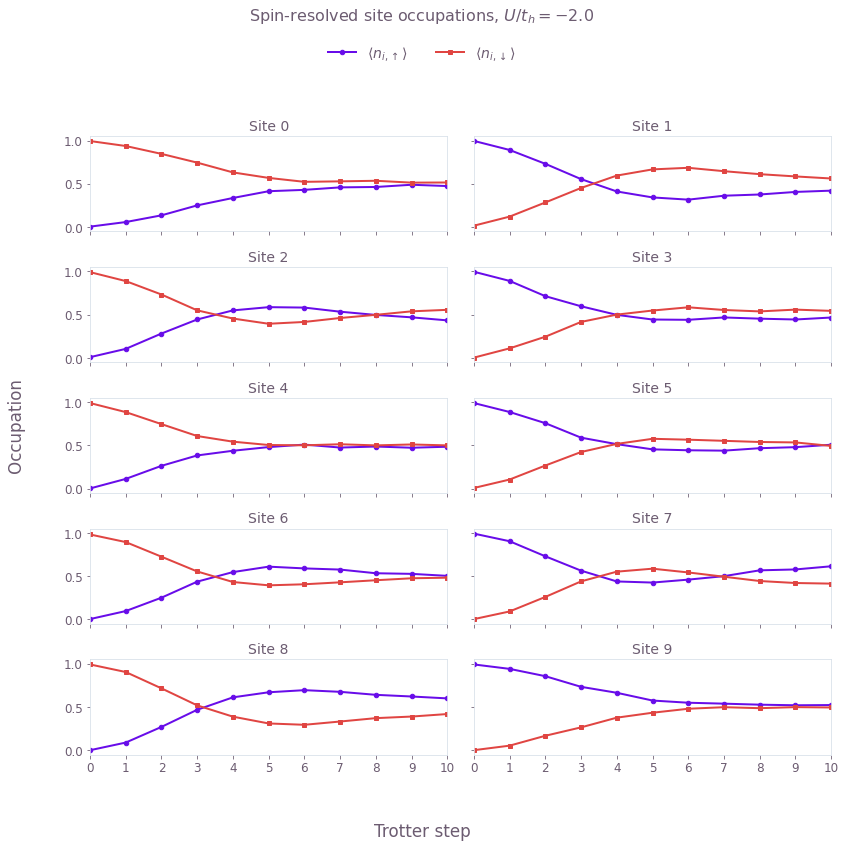

In [ ]:
result_expectation_values = result.result()["observable_expectation_values"]

n_data_points = len(result_expectation_values[0])
completed_steps = n_data_points - 1

occ = np.asarray(result_expectation_values, dtype=float).reshape(L, 2, n_data_points)

print(f"Data points: {n_data_points} " f"(Trotter steps 0 through {completed_steps})")
print(f"Occupation range: [{occ.min():.3f}, {occ.max():.3f}]")

trotter_steps = np.arange(n_data_points)

sites_to_plot = list(range(L))
n_columns = 2
n_rows = int(np.ceil(len(sites_to_plot) / n_columns))

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_columns, figsize=(12, 2.35 * n_rows), sharex=True, sharey=True
)

axes = np.atleast_1d(axes).ravel()

spin_up_line = None
spin_down_line = None

for panel_index, site in enumerate(sites_to_plot):
    ax = axes[panel_index]

    (spin_up_line,) = ax.plot(
        trotter_steps,
        occ[site, 0],
        color=colors[0],
        marker="o",
        markersize=4.5,
        linewidth=2.0,
        label=r"$\langle n_{i,\uparrow}\rangle$",
    )

    (spin_down_line,) = ax.plot(
        trotter_steps,
        occ[site, 1],
        color=colors[1],
        marker="s",
        markersize=4.2,
        linewidth=2.0,
        label=r"$\langle n_{i,\downarrow}\rangle$",
    )

    ax.set_title(f"Site {site}")
    ax.set_xlim(trotter_steps[0], trotter_steps[-1])
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(trotter_steps)

for ax in axes[len(sites_to_plot) :]:
    ax.set_visible(False)

fig.suptitle(rf"Spin-resolved site occupations, $U/t_h={U / t:.1f}$", y=0.995)

fig.supxlabel("Trotter step")
fig.supylabel("Occupation")

fig.legend(
    handles=[spin_up_line, spin_down_line],
    labels=[r"$\langle n_{i,\uparrow}\rangle$", r"$\langle n_{i,\downarrow}\rangle$"],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=2,
    frameon=False,
)

fig.tight_layout(rect=(0.03, 0.03, 1.0, 0.92))

plt.show()

As the evolution proceeds, hopping delocalizes the fermions and the attractive interaction correlates them, so the initial order relaxes toward half-filling and the two spin curves on each site cross and move toward $0.5$. Particle number is conserved, so the pair on every site stays a near-mirror image about $0.5$ and the total occupation holds at roughly one fermion per site throughout. Most sites reach $\langle n\rangle \approx 0.5$ within a few steps, while a few keep mild damped oscillations and a small residual polarization out to step 10, consistent with the finite length of the chain. The smooth, low-noise curves and the clean spin symmetry reflect Fire Opal's error suppression running on hardware.

In [23]:
from fireopal import print_package_versions

print_package_versions()

| Package               | Version |
| --------------------- | ------- |
| Python                | 3.12.11 |
| matplotlib            | 3.10.3  |
| networkx              | 3.2.1   |
| numpy                 | 2.5.1   |
| sympy                 | 1.14.0  |
| fire-opal             | 11.2.0  |
| qctrl-visualizer      | 9.0.0   |
| qctrl-workflow-client | 9.0.1   |
